In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Differentiation

## Single Variable

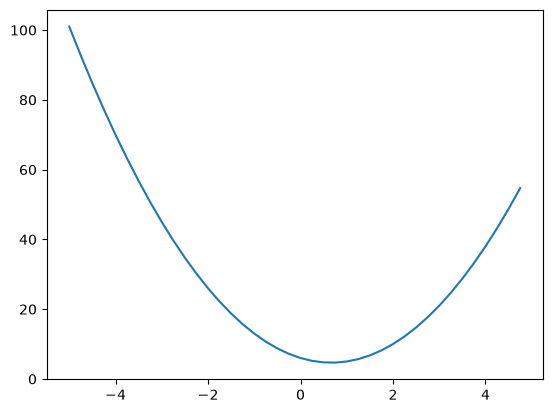

In [8]:
def f(x):
    out = 3 * x**2 - 4 * x + 6
    return out


xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [9]:
x = 2.0
h = 0.001
(f(x + h) - f(x)) / h

8.003000000000426

In [10]:
x = -2.0
h = 0.001
(f(x + h) - f(x)) / h

-15.996999999998707

## Multi Variable

In [ ]:
%%time
h = 0.001

a = 2.0
b = -3.0
c = 10
d1 = a * b + c

# a = 2.0 + h
b = -3.0 + h
c = 10
d2 = a * b + c

(d2-d1)/h

CPU times: total: 0 ns
Wall time: 13.1 μs


1.9999999999997797

In [1]:
1+1

2

In [61]:
class Value:
    def __init__(self, data, _prev=(), _op="", label=""):
        self.data = data
        self._prev = list(_prev)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data = {self.data}, _op = {self._op})"

    def __add__(self, other):
        t = Value(self.data + other.data, _prev=[self, other], _op="+")
        return t

    def __mul__(self, other):
        t = Value(self.data * other.data, _prev = [self, other], _op = "*")
        return t


a = Value(2.0)
a.label = "a"
b = Value(-3.0)
b.label = "b"
c = Value(10.0)
c.label = "c"
# d = a * b; d.label = 'd'
d = a * b + c
d.label = "d"
d

Value(data = 4.0, _op = +)

In [15]:
def add_item(x, bucket=[]):
    bucket.append(x)
    return bucket

print(add_item(1))
print(add_item(2))
print(add_item(3))

[1]
[1, 2]
[1, 2, 3]


In [47]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a * b + c

# def trace(root):
#     
# 
# nodes, edges = trace(d)
# assert len(nodes) == 5      # a, b, c, (a*b), d
# assert len(edges) == 4

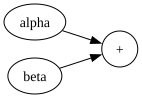

In [35]:
import os
os.environ["PATH"] += os.pathsep + r"C:\\Program Files\\Graphviz\\bin"
from graphviz import Digraph

g = Digraph(format="svg", graph_attr={"rankdir": "LR"})   # LR = ซ้ายไปขวา

g.node(name="n1", label="alpha")          # name = id ภายใน (ห้ามซ้ำ)
g.node(name="n2", label="beta")           # label = ตัวอักษรที่โชว์บนรูป
g.node(name="op1", label="+", shape="circle")

g.edge("n1", "op1")                       # ลูกศรอ้างอิงด้วย name ไม่ใช่ label
g.edge("n2", "op1")

g                                          # พิมพ์ตัวแปรเฉยๆ → โน้ตบุ๊กวาดให้เลย


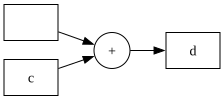

In [ ]:
root = d
g = Digraph(format="svg", graph_attr={"rankdir": "LR"})   # LR = ซ้ายไปขวา
g.node(name=str(id(root)), label=root.label, shape="record")
g.node(name=str(id(root))+root._op, label=root._op, shape="circle")
g.edge(str(id(root))+root._op, str(id(root)))

g.node(name=str(id(root._prev[0])), label=root._prev[0].label, shape="record")
g.node(name=str(id(root._prev[1])), label=root._prev[1].label, shape="record")
g.edge(str(id(root._prev[0])), str(id(root))+root._op)
g.edge(str(id(root._prev[1])), str(id(root))+root._op)

g

In [ ]:
def trace(root: Value):
    nodes = []
    node = root
    nodes.append(node)
    if node._prev == []:
        return []
    for i in range(len(node._prev)):
        nodes.append(trace(node._prev[i]))
        
    return nodes

In [100]:
import pprint

def trace(root: Value):
    nodes = set()
    edges = []
    
    def f(node: Value):
        nodes.add(node)
        for n in node._prev:
            f(n)
            edges.append((n, node))
        
    f(root)
    return nodes, edges

nodes, edges = trace(d)
pprint.pp(edges)

[(Value(data = 2.0, _op = ), Value(data = -6.0, _op = *)),
 (Value(data = -3.0, _op = ), Value(data = -6.0, _op = *)),
 (Value(data = -6.0, _op = *), Value(data = 4.0, _op = +)),
 (Value(data = 10.0, _op = ), Value(data = 4.0, _op = +))]


In [97]:
s = set()
s.add(2)
s.add(1)
s

{1, 2}

In [93]:
x = Value(1.0)
y = Value(2.0)
z = x * y + x
nodes = trace(z)
nodes


{Value(data = 1.0, _op = ),
 Value(data = 2.0, _op = ),
 Value(data = 2.0, _op = *),
 Value(data = 3.0, _op = +)}

In [75]:
nodes = trace(d)
print(nodes)

[Value(data = 4.0, _op = +), [Value(data = -6.0, _op = *), [], []], []]


In [76]:
trace(d._prev[0])

[Value(data = -6.0, _op = *), [], []]

In [77]:
d._prev[0]._prev

[Value(data = 2.0, _op = ), Value(data = -3.0, _op = )]

In [69]:
x = [1]
x.append([2][0])
x

[1, 2]

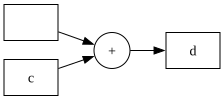

In [55]:
def trace(root):
    g = Digraph(format="svg", graph_attr={"rankdir": "LR"})   # LR = ซ้ายไปขวา
    g.node(name=str(id(root)), label=root.label, shape="record")
    g.node(name=str(id(root))+root._op, label=root._op, shape="circle")
    g.edge(str(id(root))+root._op, str(id(root)))

    g.node(name=str(id(root._prev[0])), label=root._prev[0].label, shape="record")
    g.node(name=str(id(root._prev[1])), label=root._prev[1].label, shape="record")
    g.edge(str(id(root._prev[0])), str(id(root))+root._op)
    g.edge(str(id(root._prev[1])), str(id(root))+root._op)
    
    return g

g = trace(d)
g

In [ ]:
def trace(root):
    g = Digraph(format="svg", graph_attr={"rankdir": "LR"})   # LR = ซ้ายไปขวา
    while root._prev != []:
        g.node(name=str(id(root)), label=root.label, shape="record")
        g.node(name=str(id(root))+root._op, label=root._op, shape="circle")
        g.edge(str(id(root))+root._op, str(id(root)))

        g.node(name=str(id(root._prev[0])), label=root._prev[0].label, shape="record")
        g.node(name=str(id(root._prev[1])), label=root._prev[1].label, shape="record")
        g.edge(str(id(root._prev[0])), str(id(root))+root._op)
        g.edge(str(id(root._prev[1])), str(id(root))+root._op)
    
    return g

g = trace(d)
g

In [60]:
i = 1
while i<10:
    print(i)
    i += 1

1
2
3
4
5
6
7
8
9


In [58]:
root._prev

[Value(data = -6.0, _op = *), Value(data = 10.0, _op = )]

In [49]:
d

Value(data = 4.0, _op = +)

In [52]:
d._prev[0].label

''

In [32]:
trace(d)

In [25]:
str(id(d))

'2645512588944'